In [1]:
# Import library yang digunakana
import cv2
from PIL import Image, ImageFilter
import skimage as skm
import matplotlib.pyplot as plt
import numpy as np
from PIL.ExifTags import TAGS

# Pengatar Citra Digital

Citra digital merupakan representasi dua dimensi dari citra yang direpresentasikan secara numerik dalam bentuk diskrit. Citra digital dibentuk dari kumpulan titik-titik yang disebut piksel (picture element).

1. **Definisi Formal**, Citra digital dapat didefinisikan sebagai fungsi f(x,y) dimana x dan y adalah koordinat spasial, dan f adalah intensitas atau tingkat keabuan pada koordinat tersebut.
2. **Interpretasi Matematis**, Citra digital dapat direpresentasikan sebagai matriks MxN dimana M adalah jumlah baris dan N adalah jumlah kolom. Setiap elemen matriks merepresentasikan nilai intensitas.
3. **Signifikansi**, Pemahaman mendalam tentang citra digital menjadi fondasi penting dalam pengembangan aplikasi computer vision tingkat lanjut.

## Representasi Citra Digital

Citra digital direpresentasikan sebagai matriks dengan ukuran MxN, dengan setiap elemen matriks mewakili nilai intensitas piksel.

Untuk citra grayscale, setiap piksel memiliki satu nilai intensitas, sedangkan untuk citra berwarna (RGB), setiap piksel memiliki tiga nilai intensitas yang mewakili komponen merah, hijau, dan biru.

In [2]:
img_1 = cv2.imread("./assets/SC.jpeg")
img_true = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_1, cv2.COLOR_BGR2GRAY)

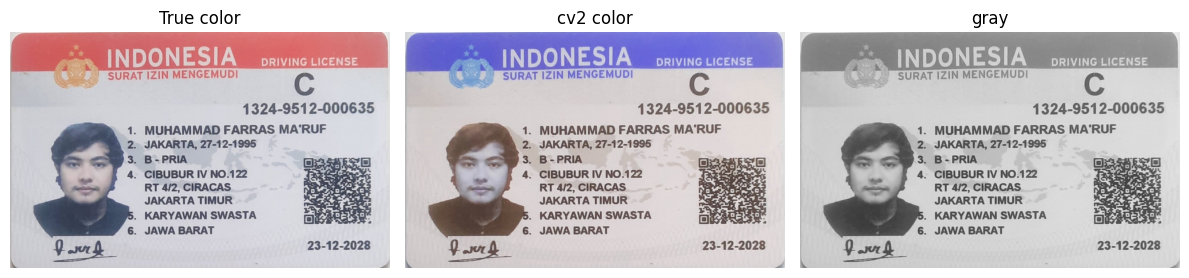

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(12,4))

ax[0].imshow(img_true)
ax[0].set_title("True color")

ax[1].imshow(img_1[:])
ax[1].set_title("cv2 color")

ax[2].imshow(img_gray[:], cmap='gray', vmin=0, vmax=255)
ax[2].set_title("gray")
for a in ax:
    a.axis("off")
plt.tight_layout()
plt.show()

In [4]:
print(f"Image BGR : {img_1.ndim}, shape : {img_1.shape}")
# Or 
print(f"Image true : {img_true.ndim}, shape : {img_true.shape}")
# Or
print(f"Image gray : {img_gray.ndim}, shape : {img_gray.shape}")

Image BGR : 3, shape : (928, 1492, 3)
Image true : 3, shape : (928, 1492, 3)
Image gray : 2, shape : (928, 1492)


Jika sulit dalam melihat bentuk array pada gambar asli berikut adalah contoh yg lebih simple untuk mengetahui nilai matrix antara gambar denga channel warna dan dengan grayscale

(2, 2, 3)


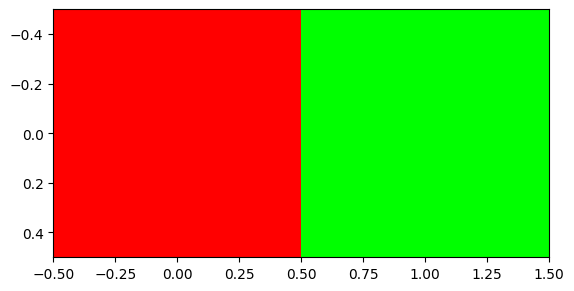

In [5]:
cret_img = np.array([[[255,0,0],[0,255,0]],
           [[0,255,0],[255,0,0]]])
print(cret_img.shape)
plt.imshow(cret_img[:1:])
plt.show()

(2, 2)


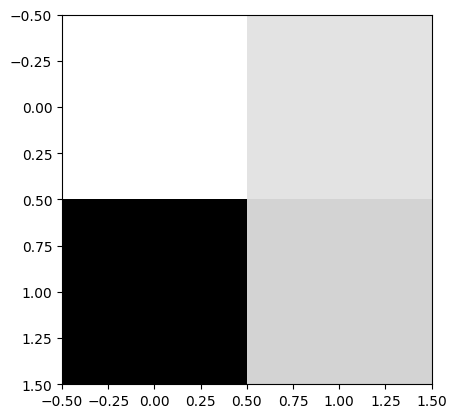

In [6]:
cret_img_gray = np.array([[255,230]
                          ,[20,215]])
print(cret_img_gray.shape)
plt.imshow(cret_img_gray[:], cmap="gray")
plt.show()

## Karakteristik Citral Digital

1. **Resolusi Spasial**, Mengacu pada jumlah piksel per satuan panjang (ppi - pixel per inch). Semakin tinggi resolusi spasial, semakin detail citra yang dihasilkan. Resolusi 300 ppi biasanya dianggap sebagai standar minimum untuk pencetakan berkualitas tinggi.
2. **Resolusi Piksel**, Mengacu pada jumlah total piksel dalam citra, dinyatakan sebagai lebar × tinggi (misal: 1920×1080). Semakin banyak piksel, semakin besar ukuran file. Citra beresolusi tinggi memerlukan ruang penyimpanan dan daya komputasi yang lebih besar untuk diproses.
3. **Resolusi Radiometrik**, Mengacu pada jumlah bit yang digunakan untuk menyimpan informasi warna per piksel. Semakin banyak bit, semakin banyak tingkat keabuan atau warna yang dapat direpresentasikan. Citra 8-bit grayscale memiliki 256 tingkat keabuan, sementara citra 24-bit RGB memiliki 16,7 juta warna.

## Karakteristik Citra Digital: Intensitas dan Warna

**Intensitas Piksel**
* Merepresentasikan tingkat kecerahan pada setiap piksel
* Untuk citra grayscale, nilai intensitas berkisar antara 0 (hitam) hingga 255 (putih) pada citra 8-bit
* Histogram intensitas menggambarkan distribusi tingkat keabuan dalam citra

**Model Warna**
* RGB (Red-Green-Blue): Model aditif yang umum digunakan pada layar digital
* CMYK (Cyan-Magenta-Yellow-Key): Model subtraktif untuk keperluan pencetakan
* HSV (Hue-Saturation-Value): Model yang memisahkan informasi warna (hue) dari intensitas (value)
* Grayscale: Representasi citra dengan satu kanal intensitas

## Karakteristik Citra Digital: Format File
**Format Lossless**, Format yang mempertahankan semua informasi asli tanpa kompresi yang mengurangi kualitas.

* PNG (Portable Network Graphics): Mendukung transparansi, ideal untuk grafik web
* TIFF (Tagged Image File Format): Format fleksibel dengan kualitas tinggi untuk pengarsipan
* BMP (Bitmap): Format tanpa kompresi dengan ukuran file besar

**Format Lossy**, Format yang menggunakan kompresi dengan mengorbankan beberapa detail untuk mengurangi ukuran file.
* JPEG (Joint Photographic Experts Group): Kompresi tinggi, ideal untuk foto
* WebP: Format modern dengan kompresi lebih baik dari JPEG
* JPEG 2000: Penyempurnaan JPEG dengan performa kompresi lebih baik

**Format Khusus Computer Vision**, Format yang sering digunakan dalam aplikasi pemrosesan citra dan computer vision.
* OpenEXR: Format dengan dynamic range tinggi untuk aplikasi VFX
* Raw: Format mentah dari sensor kamera, menyimpan semua informasi sensor
* HDF5: Format hierarkis untuk menyimpan data citra multidimensi

## Ekstract Medata Data Object (Menggunakan Pillow)

In [7]:
## Membuat function ekstraction
pil_img = Image.open("./assets/SC.jpeg")
exif = pil_img._getexif()

if pil_img:
    print(dir(pil_img))
    # for a,b in exif.items():
    #     print(TAGS.get(a),b)

['_Image__transformer', '__annotations__', '__array_interface__', '__arrow_c_array__', '__arrow_c_schema__', '__class__', '__copy__', '__delattr__', '__dict__', '__dir__', '__doc__', '__enter__', '__eq__', '__exit__', '__firstlineno__', '__format__', '__ge__', '__getattr__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__setstate__', '__sizeof__', '__static_attributes__', '__str__', '__subclasshook__', '__weakref__', '_attach_default_encoderinfo', '_close_exclusive_fp_after_loading', '_close_fp', '_copy', '_crop', '_dump', '_ensure_mutable', '_exclusive_fp', '_exif', '_exif_offset', '_expand', '_get_safe_box', '_getexif', '_getmp', '_huffman_ac', '_huffman_dc', '_im', '_min_frame', '_mode', '_new', '_open', '_read_dpi_from_exif', '_readonly', '_reload_exif', '_repr_image', '_repr_jpeg_', '_repr_png_', '_repr_pretty_', '_seek_che

Krena balikan dari method `_getexif()` data dictionary dan menggunakan nomor tag atau kode, maka kita gunakan `TAGS` untuk lookup deskripsinya

## Memanipulasi Nilai Piksel

<class 'numpy.ndarray'>


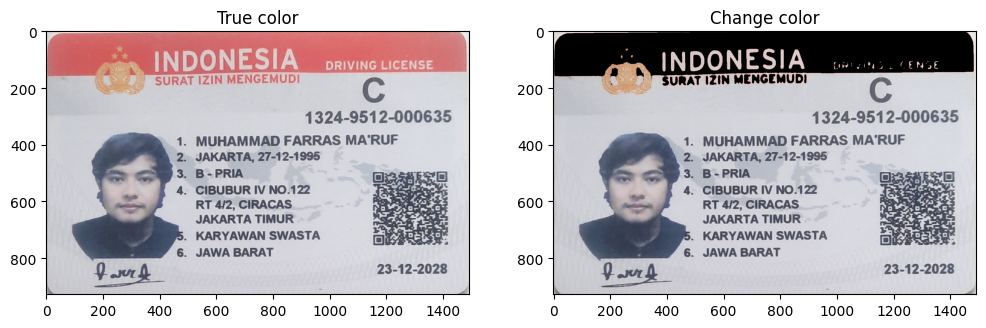

In [ ]:
merah_muda1 = np.array([0, 50, 50])
merah_tua1  = np.array([10, 255, 255])

merah_muda2 = np.array([170, 50, 50])
merah_tua2  = np.array([180, 255, 255])

changes_image = cv2.imread("./assets/SC.jpeg")
changes_image_hsv = cv2.cvtColor(changes_image, cv2.COLOR_BGR2HSV)

# Combine both red ranges
mask1 = cv2.inRange(changes_image_hsv, merah_muda1, merah_tua1)
mask2 = cv2.inRange(changes_image_hsv, merah_muda2, merah_tua2)
nilai_ganti = cv2.bitwise_or(mask1, mask2)

# Apply mask on original BGR image
changes_image[nilai_ganti > 0] = [0, 0, 0]

# Convert BGR → RGB for Matplotlib display
# changes_image_rgb = cv2.cvtColor(changes_image, cv2.COLOR_BGR2RGB)
img_true_rgb = cv2.cvtColor(cv2.imread("./assets/SC.jpeg"), cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].imshow(img_true_rgb)
ax[0].set_title("True color")

ax[1].imshow(cv2.cvtColor(changes_image, cv2.COLOR_BGR2RGB))
ax[1].set_title("Change color")
plt.show()

## Resizing (Merubah ukuran)

Open CV memiliki fungsi `cv2::resize` untuk merubah ukuran piksel gambar. Fungsi ini menyediakan parameter interpolasi (motedi matematika untuk mengetahui nilai tengah yang tidak diketahui berdasarakan titik-titik disekitarnya yang nilainya diketahui) sehingga kita dapat mengatur kualitas gambar atau kecepatan proses mengubah ukuran gambar.

OpenCV mengimplementasi dan menyediakan 10 metoda interpolasi.
1. Nearest Neighbor Interpolation
2. Bilinear interpolation
3. Bicubic interpolation
4. Pixel area relation
5. Lanczos interpolation 8X8 neighbourhood
6. Bit exact bilinear interpolation
7. Bit exact nearest neighbor interpolation
8. Mask for interpolation code
9. Flag, mengisi semua target piksel.
10. Invers Transformation 

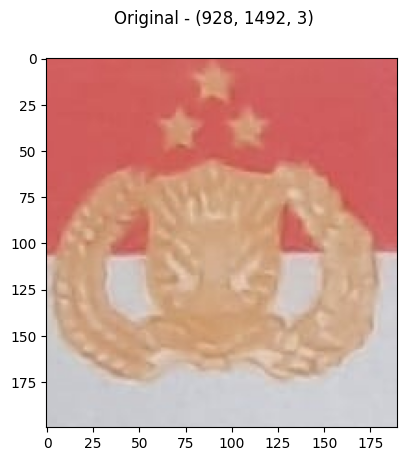

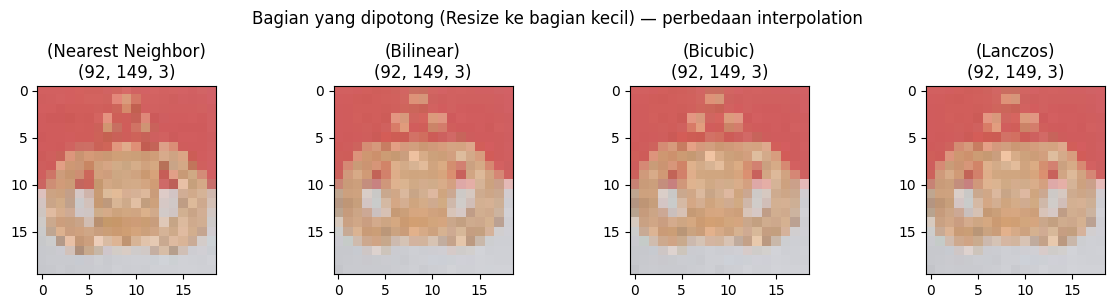

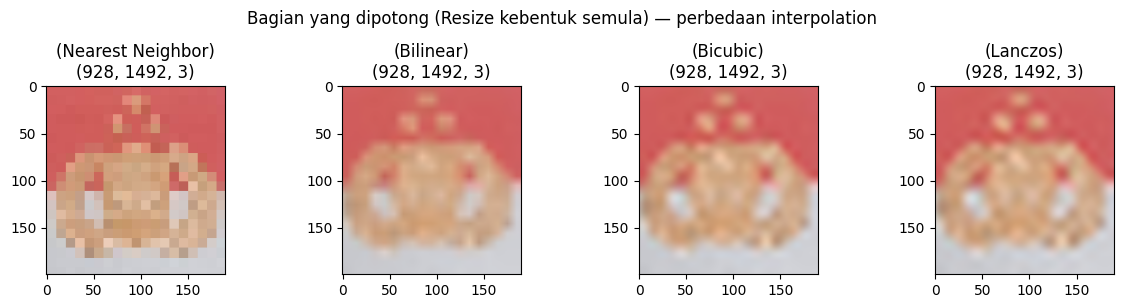

In [139]:
unresize_image = cv2.imread("./assets/SC.jpeg")
unresize_image = cv2.cvtColor(unresize_image, cv2.COLOR_BGR2RGB)  # Fix color

plt.imshow(unresize_image[50:250,170:360])
plt.suptitle(f"Original - {unresize_image.shape}")
plt.show()

fig, ax = plt.subplots(1, 4, figsize=(12, 3))
# fig, ax2 = plt.subplots(1, 4, figsize=(12, 3))

interpolasimethods = [
    ('Nearest Neighbor', cv2.INTER_NEAREST),
    ('Bilinear', cv2.INTER_LINEAR),
    ('Bicubic', cv2.INTER_CUBIC),
    ('Lanczos', cv2.INTER_LANCZOS4)
]

diperkecil = []
dikembalikan = []

for a, (name, method) in enumerate(interpolasimethods):
    small = cv2.resize(unresize_image, (unresize_image.shape[1]//10, unresize_image.shape[0]//10), interpolation=method)
    resized = cv2.resize(small, (unresize_image.shape[1], unresize_image.shape[0]), interpolation=method)
    diperkecil.append((small, name))
    dikembalikan.append((resized, name))


# Display bagian yg dipotong kecil
for i, (array, name) in enumerate(diperkecil):
    ax[i].imshow(array[5:25,17:36])
    ax[i].set_title(f"""({name})
{array.shape}""")

plt.suptitle("Bagian yang dipotong (Resize ke bagian kecil) — perbedaan interpolation", fontsize=12)
plt.tight_layout()
plt.show()

# Display bagian yang dikembalikan ke bentuk semula
fig, ax = plt.subplots(1, 4, figsize=(12, 3))
for i, (array, name) in enumerate(dikembalikan):
    ax[i].imshow(array[50:250,170:360])
    ax[i].set_title(f"""({name})
{array.shape}""")

plt.suptitle("Bagian yang dipotong (Resize kebentuk semula) — perbedaan interpolation", fontsize=12)
plt.tight_layout()
plt.show()
